In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import norm
from Calvet_MSM_Gab import *


In [142]:
# Step 1: Load the CSV data
print("Loading the data from CSV...")
df = pd.read_csv("BTC-USD.csv", parse_dates=["Date"], index_col="Date")
start_date = '2024-01-01'
end_date = '2025-02-28'
# Convert to datetime
end_date = pd.to_datetime(end_date)
df_train = df.loc[start_date:end_date - pd.Timedelta(days=15)]
df = df.loc[start_date:end_date]  # Filter data between start_date and end_date
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespaces from column names
df_train.columns = df_train.columns.str.strip()
print("Data loaded and filtered between dates:", start_date, "and", end_date)

# Step 2: Calculate the daily log returns
print("Calculating the daily log returns...")
df['Log_Ret'] = np.log(df['Price'] / df['Price'].shift(1))
df_train['Log_Ret'] = np.log(df_train['Price'] / df_train['Price'].shift(1))
print("Log returns calculated.")

Loading the data from CSV...
Data loaded and filtered between dates: 2024-01-01 and 2025-02-28 00:00:00
Calculating the daily log returns...
Log returns calculated.


In [143]:
# parameters MSM
print("Step 6: Estimating parameters for the MSM...")
niter = 1
temperature = 1.0
stepsize = 1.0
k_bar = 4
data = df_train['Log_Ret'].values[:, np.newaxis]
data = data[1:]
#print(data)
parameters, LL, niter, output = glo_min(k_bar, data, niter, temperature, stepsize)
print(LL)
# name parameters for later use:
b = parameters[0]
m_0 = parameters[1]
gamma_kbar = parameters[2]
sigma = parameters[3]

pi_t = g_pi_t(m_0,k_bar,data,[b, gamma_kbar, sigma])[-1,:]
A = g_t(k_bar, b, gamma_kbar)

print("Parameters from glo_min for Simulated dataset: ", "\n"
      "kbar = ", k_bar,"\n"
      'b = %.5f' % b,"\n"
      'm_0 = %.5f' % m_0,"\n"
      'gamma_kbar = %.5f' % gamma_kbar,"\n"
      'sigma = %.5f' % sigma,"\n")

Step 6: Estimating parameters for the MSM...
-915.4481684337995
Parameters from glo_min for Simulated dataset:  
kbar =  4 
b = 1.49995 
m_0 = 1.42023 
gamma_kbar = 0.95146 
sigma = 0.02714 



In [144]:
def compute_state_vols(m0, k_bar, sigma):
        m1 = 2-m0
        """Computes the volatility values for each of the 2**k_bar states in the MSM."""
        states = np.array([m0**(k_bar - np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int))) *
                        m1**(np.sum(np.array(list(np.binary_repr(i, width=k_bar)), dtype=int)))
                        for i in range(2**k_bar)])
        states = sigma*np.sqrt(states)
        return states

def msm_volatilite_instantanee(pi_t, m0, k_bar, sigma):
        """retourne un array de taille pi_t"""
        state_vols = compute_state_vols(m0, k_bar, sigma)
        return np.dot(pi_t, state_vols)


def simulate_paths(simulations, price):
    "transforme log return en prix"
    N, T = simulations.shape
    simulations_path = np.zeros((N, T + 1))  # Include initial price in paths

    for i in range(N):  # Iterate over simulations
        logret = simulations[i, :]  # Select row i
        path = np.zeros(T + 1)
        path[0] = price  # Set initial price
        for t in range(1, T + 1):  # Start from 1
            path[t] = path[t - 1] * np.exp(logret[t - 1])  # Apply geometric return formula
        simulations_path[i, :] = path  # Store full path
    # print("path")
    # print(simulations_path[:, 1])  # Second column, first step after initial price
    return simulations_path

def monte_carlo_markov(N, T, A, pi_t, m0, k_bar, sigma):
    variance_vect = compute_state_vols(m0, k_bar, sigma)
    #simuler msm à partir de pi_t
    num_states = len(pi_t)
    simulations = np.zeros((N, T))  
    sigma_array = np.zeros((N, T)) 
    stationary_dist = np.linalg.matrix_power(A, 1000)[0]
    for i in range(N):
        state = np.random.choice(num_states, p=pi_t)  # Start from initial distribution

        for t in range(T):
            sigma = variance_vect[state]
            simulations[i, t] = np.random.normal(scale = sigma)
            sigma_array[i, t] = sigma
            state = np.random.choice(num_states, p=A[state, :])
    # print("simu")
    # print(simulations)
    return(simulations, sigma_array)




N = 5000
T = 30
simulation_lr,volatilite_mat = monte_carlo_markov(N,T,A,pi_t,m_0,k_bar,sigma)
price = df_train['Price'].iloc[-1]
simulation_p = simulate_paths(simulation_lr,price)
simulation_vol = np.std(simulation_lr, axis = 0)
volatilite_arr = np.mean(volatilite_mat, axis = 0)
print(simulation_vol) 
#diff = simulation_vol - volatilite_arr
#print("Décalage moyen :", np.mean(diff))

[0.02408766 0.02653219 0.02653353 0.02619537 0.0269629  0.02697064
 0.02667939 0.02809325 0.02744515 0.02685926 0.0272277  0.02756984
 0.02636762 0.02727348 0.0268064  0.02726813 0.0265885  0.02766701
 0.02696385 0.02717074 0.02753471 0.02644995 0.02726161 0.0273491
 0.02718401 0.02684796 0.0264979  0.0273247  0.02691686 0.02641215]


In [145]:
print(T)
def calculate_mae(true_vol, forecast_vol):
    return np.mean(np.abs(true_vol - forecast_vol))


data_real = df_train['Log_Ret'].values[:, np.newaxis]
data_real = data_real[1:]
data = df['Log_Ret'].values[:, np.newaxis]
data = data[1:]

msm_fit_volatility = compute_MSM_vol(data_real,parameters, k_bar)[0]
msm_fit_volatility_tot = compute_MSM_vol(data,parameters, k_bar)[0]

def historical_volatility(logret, window=30):
    return logret.rolling(window=window).std()

historical_vol = historical_volatility(df['Log_Ret'], 30)
def ewma_volatility(returns, span=30):
    return returns.ewm(span=span).std() # Exponentially weighted moving average
# Set the lambda value for the EWMA model (usually between 0.94 and 0.98)
lambda_ewma = 0.94

# Calculate the EWMA volatility (standard deviation)
ewma_vol = df['Log_Ret'].ewm(span=(2 / (1 - lambda_ewma)), adjust=False).std()   # Annualized volatility



30


Step 10: Calculating Mean Absolute Error (MAE)...
Step 11: Plotting historical and simulated volatility...
pourcentage d'indices où Log-Ret < volatilité estimée : 0.1


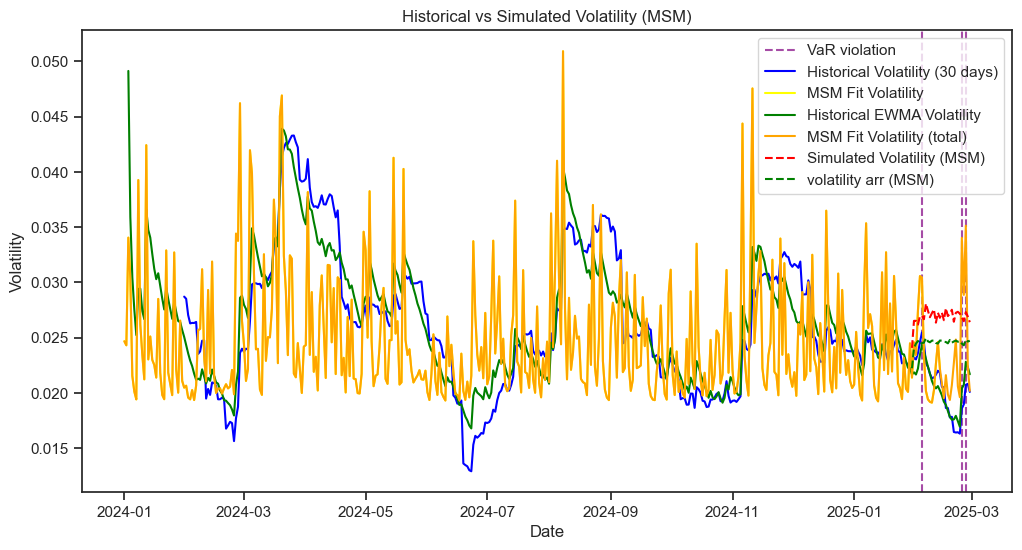

Step 12: Mean Absolute Error (MAE) between Historical Volatility and Simulated Volatility: 0.006189130697426063


In [146]:
# Calculate MAE between simulated volatility and historical volatility
print("Step 10: Calculating Mean Absolute Error (MAE)...")
mae = calculate_mae(historical_vol[-T:].values, simulation_vol)

# Plotting the results
print("Step 11: Plotting historical and simulated volatility...")
plt.figure(figsize=(12, 6))
# Seuil de VaR (10e percentile de la distribution normale standard)
#var_threshold = volatilite_arr * stats.norm.ppf(0.10)
var_threshold = simulation_vol * stats.norm.ppf(0.10)
indices_below = df['Log_Ret'].index[-T:][df['Log_Ret'][-T:] < var_threshold]
# Ajout des asymptotes verticales aux dates des violations de la VaR
for date in indices_below:
    plt.axvline(x=date, color='purple', linestyle='--', alpha=0.7, label="VaR violation" if date == indices_below[0] else "")
# Nombre d'instants où Log-Ret < volatilité estimée
print(f"pourcentage d'indices où Log-Ret < volatilité estimée : {len(indices_below)/T}")

# Plot historical volatility
plt.plot(historical_vol.index, historical_vol, label="Historical Volatility (30 days)", color='blue')
plt.plot(df_train.index, msm_fit_volatility, label="MSM Fit Volatility", color='yellow')
plt.plot(ewma_vol.index, ewma_vol, label="Historical EWMA Volatility", color='green')
plt.plot(df.index, msm_fit_volatility_tot, label="MSM Fit Volatility (total)", color='orange')
#print(historical_vol[-T+1:])
# Plot simulated volatility (average of simulations)
plt.plot(historical_vol.index[-T:], simulation_vol, label="Simulated Volatility (MSM)", color='red', linestyle='--')
plt.plot(historical_vol.index[-T:], volatilite_arr, label="volatility arr (MSM)", color='green', linestyle='--')


#print(simulated_vol)
# Adding labels and title
plt.title('Historical vs Simulated Volatility (MSM)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend(loc="best")
plt.savefig("outofsample")
plt.show()

# Print MAE
print(f"Step 12: Mean Absolute Error (MAE) between Historical Volatility and Simulated Volatility: {mae}")


In [147]:
garch_model = arch_model(data, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch_model.fit(disp='off')

# Forecast T steps ahead
garch_forecast = garch_fit.forecast(horizon=T)

# Extract conditional volatility forecasts
garch_vol_forecast = np.sqrt(garch_forecast.variance.values[-1])  # shape: (T,)

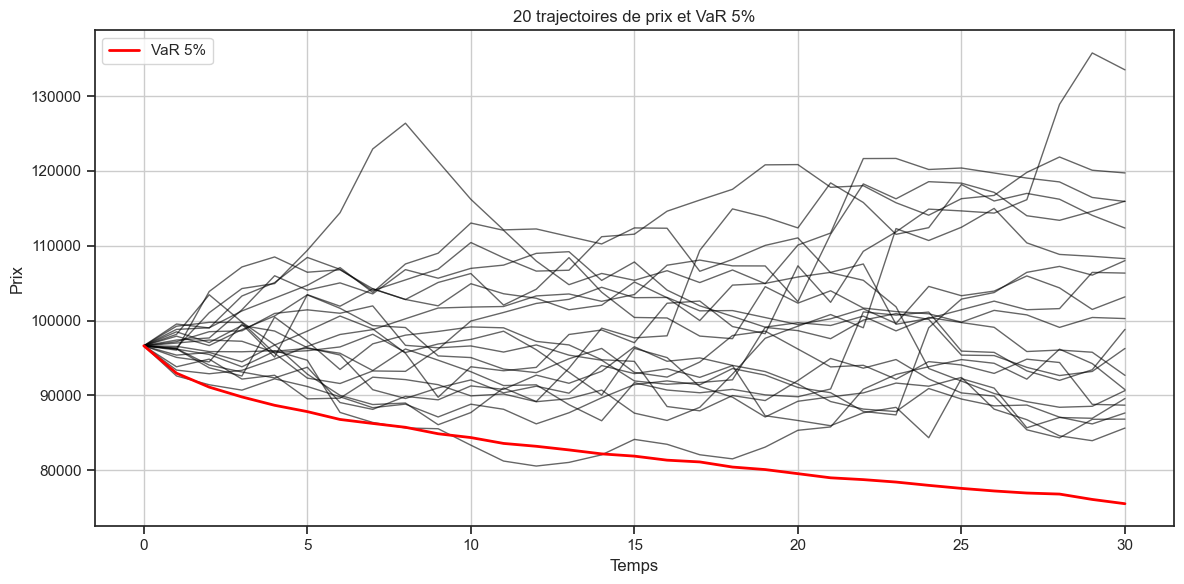

In [148]:
def compute_var(price_paths, percentile=5):
    return np.percentile(price_paths, percentile, axis=0)

def plot_paths_with_var(price_paths, var_path, num_paths_to_plot=20, percentile=5):
    T_plus_1 = price_paths.shape[1]
    time = np.arange(T_plus_1)

    # Sélectionner 20 trajectoires aléatoires
    selected_indices = np.random.choice(price_paths.shape[0], num_paths_to_plot, replace=False)
    selected_paths = price_paths[selected_indices]

    plt.figure(figsize=(12, 6))
    for path in selected_paths:
        plt.plot(time, path, color = 'black', alpha=0.6, linewidth=1)

    plt.plot(time, var_path, color='red', label=f'VaR {percentile}%', linewidth=2)
    plt.title(f"20 trajectoires de prix et VaR {percentile}%")
    plt.xlabel("Temps")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


var_path = compute_var(simulation_p, percentile=5)
plot_paths_with_var(simulation_p, var_path, num_paths_to_plot=20, percentile=5)

In [149]:
def predict_MSM_roll(T, n_window):
    vol_predictions = []
    sigma_vect = []

    for i in range(n_window):
        # Compute the shifting end date for each window
        current_end = end_date - pd.Timedelta(days=(n_window - i - 1) * T)

        # Extract training data
        ndf_train = df.loc[start_date:end_date - (n_window-i)*pd.Timedelta(days=T)]
        ndata = ndf_train['Log_Ret'].values[:, np.newaxis]
        ndata = ndata[1:]
        n_pi_t = g_pi_t(m_0,k_bar,ndata,[b, gamma_kbar, sigma])[-1,:]
        #print(n_pi_t)
        #print(pi_t)

        # Monte Carlo simulation
        simulation_lr, vol_m = monte_carlo_markov(N, T, A, n_pi_t, m_0, k_bar, sigma)

        # Compute volatility (std dev) of the simulations
        simulation_vol = np.std(simulation_lr, axis=0)
        sigma_arr = np.mean(vol_m, axis=0)  # shape (T,)

        # Append
        vol_predictions.append(simulation_vol)
        sigma_vect.extend(sigma_arr.tolist())  # 👈 flatten to list of floats

        print("Rolling window " + str(i + 1) + " complete")

    # Flatten vol_predictions to 1D array
    vol_predictions = np.concatenate(vol_predictions)

    return vol_predictions, sigma_vect
last_month_exp_vol_rolling, last_month_sigma_roll = predict_MSM_roll(3,10)
print(last_month_exp_vol_rolling)

Rolling window 1 complete
Rolling window 2 complete
Rolling window 3 complete
Rolling window 4 complete
Rolling window 5 complete
Rolling window 6 complete
Rolling window 7 complete
Rolling window 8 complete
Rolling window 9 complete
Rolling window 10 complete
[0.02584071 0.02733049 0.02723841 0.02553436 0.02653631 0.02696295
 0.03221451 0.02833085 0.02766782 0.02109729 0.02569023 0.02661473
 0.02242079 0.02594612 0.02664372 0.02409883 0.02616516 0.02689772
 0.02344604 0.02583636 0.02666411 0.02261449 0.02660744 0.02762241
 0.02311033 0.02663513 0.02758306 0.03057602 0.02872266 0.02723971]


Date
2025-01-30    0.022736
2025-01-31    0.023194
2025-02-01    0.023047
2025-02-02    0.023628
2025-02-03    0.024600
2025-02-04    0.025488
2025-02-05    0.024562
2025-02-06    0.022675
2025-02-07    0.022376
2025-02-08    0.021753
2025-02-09    0.021342
2025-02-10    0.021402
2025-02-11    0.021665
2025-02-12    0.022023
2025-02-13    0.021836
2025-02-14    0.020558
2025-02-15    0.020524
2025-02-16    0.018653
2025-02-17    0.018650
2025-02-18    0.017803
2025-02-19    0.017856
2025-02-20    0.016483
2025-02-21    0.016437
2025-02-22    0.016460
2025-02-23    0.016336
2025-02-24    0.018609
2025-02-25    0.018982
2025-02-26    0.020749
2025-02-27    0.020837
2025-02-28    0.020107
Name: Log_Ret, dtype: float64


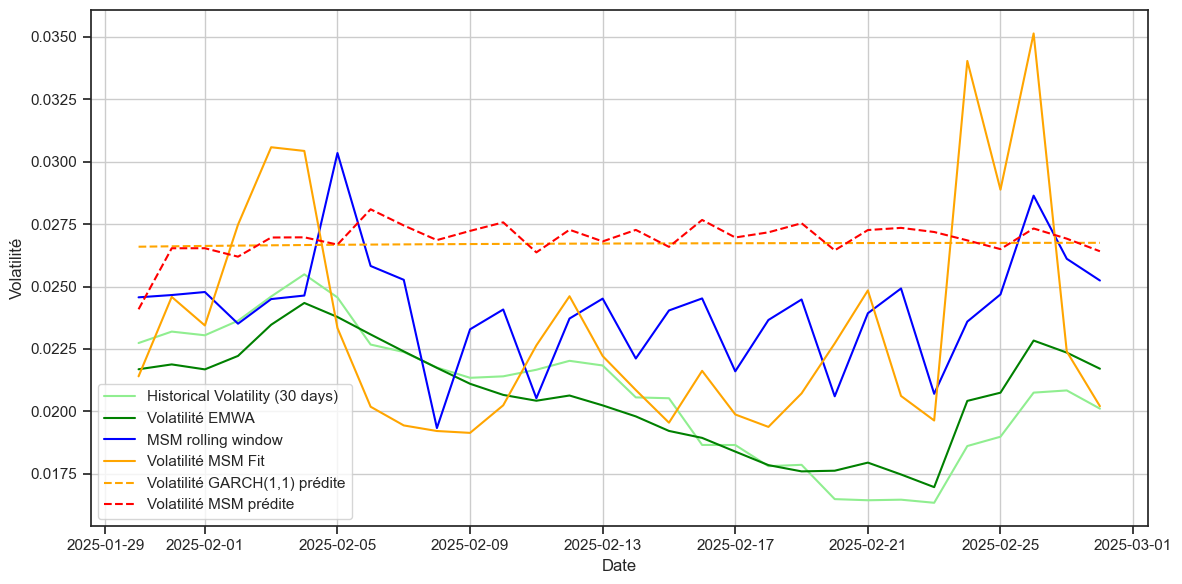

In [150]:
last_month_hist_vol = historical_vol[-T:] 
last_month_exp_vol = ewma_vol[-T:] 
last_month_returns = df['Log_Ret'][-T:]    
last_month_index = last_month_hist_vol.index
last_month_fit_vol = msm_fit_volatility_tot[-T:]


plt.figure(figsize=(12, 6))

# # VaR threshold pour chaque jour simulé
var_threshold = volatilite_arr * stats.norm.ppf(0.1)
indices_below = last_month_index[last_month_returns < var_threshold]

# Lignes verticales sur les violations de la VaR
#for i, date in enumerate(indices_below):
    #plt.axvline(x=date, color='purple', linestyle='--', alpha=0.7, label="VaR violation" if i == 0 else "")
print(last_month_hist_vol)
# Plot: données historiques récentes
plt.plot(last_month_index, last_month_hist_vol, label="Historical Volatility (30 days)", color='lightgreen')
plt.plot(last_month_index, last_month_exp_vol, label="Volatilité EMWA", color='green')
#plt.plot(last_month_index, last_month_hist_vol, label="Volatilité historique", color='lightgreen')
#plt.plot(last_month_index, last_month_exp_vol_rolling, label="Exp Volatility Rolling window (30 days)", color='purple', linestyle='--')
plt.plot(last_month_index, last_month_sigma_roll, label="MSM rolling window", color='blue' )
plt.plot(last_month_index, last_month_fit_vol, label="Volatilité MSM Fit", color='orange')
plt.plot(last_month_index, garch_vol_forecast, label="Volatilité GARCH(1,1) prédite", color='orange', linestyle='--')
plt.plot(last_month_index, simulation_vol, label="Volatilité MSM prédite", color='red', linestyle='--')
#plt.plot(last_month_index, volatilite_arr, label="volatility arr (MSM)", color='green', linestyle='--')


plt.xlabel("Date")
plt.ylabel("Volatilité")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("outofsample_last_month")
plt.show()


In [151]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

vol1 = last_month_fit_vol
vol2 = simulation_vol
vol3 = last_month_sigma_roll
vol4 = last_month_hist_vol

vol1 = pd.Series(vol1, index=df.index[-T:])
vol2 = pd.Series(vol2, index=df.index[-T:])
vol3 = pd.Series(vol3, index=df.index[-T:])
vol4 = pd.Series(vol4, index=df.index[-T:])
def compare_vol_series(*series, names=None, reference=None, show_matrix=True):
    """
    Compare plusieurs séries temporelles de volatilité (pd.Series)
    avec MAE et RMSE. Les séries doivent partager un index de type datetime.

    Args:
        *series: séries de type pd.Series avec index de dates
        names: noms des séries (si non fournis, noms génériques seront créés)
        reference: nom d'une des séries à utiliser comme référence
        show_matrix: affiche les matrices si True

    Returns:
        (mae_df, rmse_df): DataFrames avec les scores
    """
    if names is None:
        names = [f"Series_{i}" for i in range(len(series))]

    # Combiner en DataFrame et aligner sur l'index
    df = pd.concat(series, axis=1)
    df.columns = names
    df = df.dropna()  # garde uniquement les dates communes

    mae_df = pd.DataFrame(index=names, columns=names, dtype=float)
    rmse_df = pd.DataFrame(index=names, columns=names, dtype=float)

    if reference and reference in names:
        for name in names:
            if name == reference:
                continue
            mae = mean_absolute_error(df[reference], df[name])
            rmse = mean_squared_error(df[reference], df[name], squared=False)
            mae_df.loc[reference, name] = mae
            rmse_df.loc[reference, name] = rmse
    else:
        for name1, name2 in itertools.combinations(names, 2):
            mae = mean_absolute_error(df[name1], df[name2])
            rmse = mean_squared_error(df[name1], df[name2], squared=False)
            mae_df.loc[name1, name2] = mae
            mae_df.loc[name2, name1] = mae
            rmse_df.loc[name1, name2] = rmse
            rmse_df.loc[name2, name1] = rmse

    if show_matrix:
        print("\n=== MAE Matrix ===")
        print(mae_df.round(6))
        print("\n=== RMSE Matrix ===")
        print(rmse_df.round(6))

    return mae_df, rmse_df

mae_df, rmse_df = compare_vol_series(vol1, vol2, vol3, vol4, names=["MSMsimulation", "purple", "blue", "blc"])

import matplotlib.pyplot as plt

labels = ['MSMfit', 'Historique', 'EWMA']
maes = [mae_df.loc['MSMsimulation', l] for l in labels]
rmses = [rmse_df.loc['MSMsimulation', l] for l in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, maes, width, label='MAE', color='dodgerblue')
bars2 = ax.bar(x + width/2, rmses, width, label='RMSE', color='crimson')

ax.set_ylabel("Erreur")
ax.set_title("MAE et RMSE par rapport à la volatilité simulée (MSM)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

def export_mae_rmse_to_latex(mae_df, rmse_df, reference=None, precision=6):
    """
    Exporte MAE et RMSE sous forme de tableau LaTeX avec booktabs.

    Args:
        mae_df (pd.DataFrame): matrice MAE
        rmse_df (pd.DataFrame): matrice RMSE
        reference (str): si spécifié, génère un tableau avec cette série comme référence
        precision (int): nombre de décimales

    Returns:
        str: code LaTeX
    """
    rows = []
    if reference and reference in mae_df.index:
        for target in mae_df.columns:
            if target != reference and pd.notnull(mae_df.loc[reference, target]):
                mae = mae_df.loc[reference, target]
                rmse = rmse_df.loc[reference, target]
                rows.append(f"{target} & {mae:.{precision}f} & {rmse:.{precision}f} \\\\")
        caption = f"Comparaison des séries de volatilité par rapport à {reference}"
        header = "\\textbf{Comparée à} & \\textbf{MAE} & \\textbf{RMSE} \\\\"
    else:
        for i in mae_df.index:
            for j in mae_df.columns:
                if i != j and pd.notnull(mae_df.loc[i, j]):
                    mae = mae_df.loc[i, j]
                    rmse = rmse_df.loc[i, j]
                    rows.append(f"{i} vs {j} & {mae:.{precision}f} & {rmse:.{precision}f} \\\\")
        caption = "Comparaison croisée des séries de volatilité"
        header = "\\textbf{Séries comparées} & \\textbf{MAE} & \\textbf{RMSE} \\\\"

    latex = "\\begin{table}[h!]\n\\centering\n"
    latex += f"\\caption{{{caption}}}\n"
    latex += "\\begin{tabular}{lcc}\n\\toprule\n"
    latex += header + "\n\\midrule\n"
    latex += "\n".join(rows)
    latex += "\n\\bottomrule\n\\end{tabular}\n\\label{tab:mae_rmse}\n\\end{table}"
    return latex

latex_table = export_mae_rmse_to_latex(mae_df, rmse_df, reference="MSMsimulation")
print(latex_table)


=== MAE Matrix ===
               MSMsimulation    purple      blue       blc
MSMsimulation            NaN  0.005305  0.003635  0.003592
purple              0.005305       NaN  0.003186  0.006189
blue                0.003635  0.003186       NaN  0.003676
blc                 0.003592  0.006189  0.003676       NaN

=== RMSE Matrix ===
               MSMsimulation    purple      blue       blc
MSMsimulation            NaN  0.005742  0.004299  0.005231
purple              0.005742       NaN  0.003603  0.006789
blue                0.004299  0.003603       NaN  0.004331
blc                 0.005231  0.006789  0.004331       NaN


KeyError: 'MSMfit'

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
volsimu1 = simulation_vol
volsimu2 = last_month_sigma_roll
volsimu3 = garch_vol_forecast

volref1 = last_month_fit_vol
volref2 = last_month_exp_vol
volref3 = last_month_hist_vol

volsimu1 = pd.Series(volsimu1, index=df.index[-T:])
volsimu2 = pd.Series(volsimu2, index=df.index[-T:])
volsimu3 = pd.Series(volsimu3, index=df.index[-T:])
volref1 = pd.Series(volref1, index=df.index[-T:])
volref2 = pd.Series(volref2, index=df.index[-T:])
volref3 = pd.Series(volref3, index=df.index[-T:])

def compare_simulations_grouped_by_reference(volsimus, volrefs, sim_names=None, ref_names=None, precision=6):
    """
    Crée un tableau LaTeX groupé par référence avec deux lignes par bloc : une par simulation.
    """
    if sim_names is None:
        sim_names = [f"Sim{i+1}" for i in range(len(volsimus))]
    if ref_names is None:
        ref_names = [f"Ref{j+1}" for j in range(len(volrefs))]

    rows = []
    for ref, ref_name in zip(volrefs, ref_names):
        rows.append(f"\\multirow{{{len(volsimus)}}}{{*}}{{{ref_name}}}")  # première colonne fusionnée
        for i, (sim, sim_name) in enumerate(zip(volsimus, sim_names)):
            # alignement
            df = pd.concat([sim, ref], axis=1).dropna()
            mae = mean_absolute_error(df.iloc[:, 0], df.iloc[:, 1])
            rmse = mean_squared_error(df.iloc[:, 0], df.iloc[:, 1], squared=False)
            row_start = "" if i > 0 else rows.pop()  # pour éviter la répétition du nom de référence
            rows.append(f"{row_start} & {sim_name} & {mae:.{precision}f} & {rmse:.{precision}f} \\\\")
        rows.append("\\midrule")  # séparation entre groupes

    latex = "\\begin{table}[h!]\n\\centering\n"
    latex += "\\caption{Comparaison des simulations par référence (MAE et RMSE)}\n"
    latex += "\\begin{tabular}{l l c c}\n\\toprule\n"
    latex += "\\textbf{Référence} & \\textbf{Simulation} & \\textbf{MAE} & \\textbf{RMSE} \\\\\n\\midrule\n"
    latex += "\n".join(rows[:-1])  # retire le dernier \midrule
    latex += "\n\\bottomrule\n\\end{tabular}\n\\label{tab:grouped_vol_comparison}\n\\end{table}"
    return latex

latex_code = compare_simulations_grouped_by_reference(
    volsimus=[volsimu1, volsimu2,volsimu3 ],
    volrefs=[volref1, volref2, volref3],
    sim_names=["MSM simulé", "MSM rolling window", "GARCH simulé"],
    ref_names=["Fit MSM", "EWMA", "Vol. Historique"]
)

print(latex_code)

\begin{table}[h!]
\centering
\caption{Comparaison des simulations par référence (MAE et RMSE)}
\begin{tabular}{l l c c}
\toprule
\textbf{Référence} & \textbf{Simulation} & \textbf{MAE} & \textbf{RMSE} \\
\midrule
\multirow{3}{*}{Fit MSM} & MSM simulé & 0.005305 & 0.005742 \\
 & MSM rolling window & 0.003635 & 0.004299 \\
 & GARCH simulé & 0.005150 & 0.005542 \\
\midrule
\multirow{3}{*}{EWMA} & MSM simulé & 0.006263 & 0.006656 \\
 & MSM rolling window & 0.003602 & 0.004037 \\
 & GARCH simulé & 0.006067 & 0.006410 \\
\midrule
\multirow{3}{*}{Vol. Historique} & MSM simulé & 0.006189 & 0.006789 \\
 & MSM rolling window & 0.003676 & 0.004331 \\
 & GARCH simulé & 0.005994 & 0.006529 \\
\bottomrule
\end{tabular}
\label{tab:grouped_vol_comparison}
\end{table}


In [ ]:
forecast_horizon = 30
forecast = garch_fit.forecast(horizon=forecast_horizon)

# Extract the forecasted volatility (which is the standard deviation, i.e., square root of variance)
forecasted_volatility = np.sqrt(forecast.variance.values[-1, :])

# Create a time index for the forecast period (e.g., next 30 days)
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_horizon + 1, freq='B')[1:]  # Assuming business days


AttributeError: 'numpy.ndarray' object has no attribute 'index'